<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [2]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, roc_auc_score

Populating the interactive namespace from numpy and matplotlib


In [3]:
from google.colab import drive # Если вы работаете в коллабе
drive.mount('/content/drive')

Mounted at /content/drive


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [4]:
from numpy._core.numeric import indices
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """

        X = np.hstack([np.ones((X.shape[0], 1)), X])
        if self.w0 is not None:
            self.w=self.w0.copy()
        else:
            self.w= np.random.randn(X.shape[1])

        self.loss_history.append(self.calc_loss(X, y))

        for iteration in range(self.max_iter):
            w_previous = self.w.copy()

            if self.gd_type == 'full':
                gradient = self.calc_gradient(X, y)
            else:
                idx = np.random.randint(0, X.shape[0])
                gradient = self.calc_gradient(X[idx:idx+1], y[idx:idx+1])


            self.w -= self.eta * gradient

            self.loss_history.append(self.calc_loss(X, y))

            weights_diff_norm = np.linalg.norm(self.w - w_previous)
            if weights_diff_norm < self.tolerance:
                break


        return self

    def sigmoid(self, x):
        return 1/(1+np.exp(-np.clip(x, -500, 500)))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        X = np.hstack([np.ones((X.shape[0], 1)), X])
        proba = self.sigmoid (X@self.w)

        return np.vstack([1 - proba, proba]).T


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        proba = self.predict_proba(X)[:, 1]

        return (proba >= 0.5).astype(int)


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !
        n = X.shape[0]
        predictions = self.sigmoid(X @ self.w)
        gradient = (1 / n) * X.T @ (predictions - y)
        return gradient

    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        predictions = self.sigmoid(X @ self.w)
        eps = 1e-15
        predictions = np.clip(predictions, eps, 1-eps)
        loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))

        return loss



Теперь проверим работу вашего класса на синтетических данных.

In [5]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [6]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


LogReg(gd_type='full')

In [7]:
np.random.seed(42)
# Генерация синтетических данных
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_clusters_per_class=2,
    flip_y=0.05,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Размер train: {X_train.shape}, test: {X_test.shape}")
print(f"Баланс классов в train: {np.mean(y_train):.3f}")
print(f"Баланс классов в test: {np.mean(y_test):.3f}")


Размер train: (700, 10), test: (300, 10)
Баланс классов в train: 0.501
Баланс классов в test: 0.500


In [8]:
# Обучение моделей
lr_sgd = LogReg(gd_type='stochastic', max_iter=1000, eta=0.01)
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full', max_iter=1000, eta=0.01)
lr_full.fit(X_train, y_train)

# Обучение sklearn модели
lr_sklearn = LogisticRegression()
lr_sklearn.fit(X_train, y_train)

# Предсказания вероятностей
y_pred_sgd_proba = lr_sgd.predict_proba(X_test)[:, 1]
y_pred_full_proba = lr_full.predict_proba(X_test)[:, 1]
y_pred_sklearn_proba = lr_sklearn.predict_proba(X_test)[:, 1]

# Предсказания классов
y_pred_sgd = lr_sgd.predict(X_test)
y_pred_full = lr_full.predict(X_test)
y_pred_sklearn = lr_sklearn.predict(X_test)


In [9]:
# Метрики качества
models = {
    'Метрики SGD': (y_pred_sgd_proba, y_pred_sgd),
    'Метрики Full GD': (y_pred_full_proba, y_pred_full),
    'Метрики Sklearn': (y_pred_sklearn_proba, y_pred_sklearn)
}

for name, (proba, pred) in models.items():
    roc_auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    print(f"{name:12}: ROC-AUC={roc_auc:.4f}, Accuracy={acc:.4f}")

Метрики SGD : ROC-AUC=0.4545, Accuracy=0.4700
Метрики Full GD: ROC-AUC=0.7575, Accuracy=0.6967
Метрики Sklearn: ROC-AUC=0.7521, Accuracy=0.6733


<Figure size 1500x500 with 0 Axes>

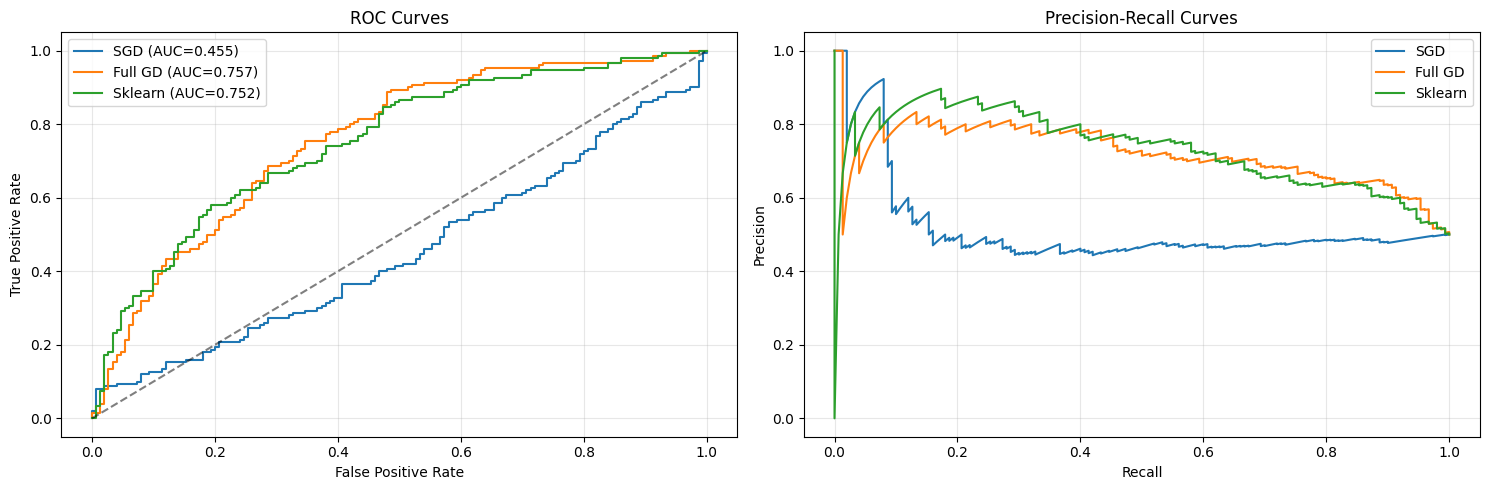

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, accuracy_score
plt.figure(figsize=(15, 5))
plt.figure(figsize=(15, 5))

# ROC кривые
plt.subplot(1, 2, 1)
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, y_pred_sgd_proba)
fpr_full, tpr_full, _ = roc_curve(y_test, y_pred_full_proba)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_pred_sklearn_proba)

plt.plot(fpr_sgd, tpr_sgd, label=f'SGD (AUC={auc(fpr_sgd, tpr_sgd):.3f})')
plt.plot(fpr_full, tpr_full, label=f'Full GD (AUC={auc(fpr_full, tpr_full):.3f})')
plt.plot(fpr_sk, tpr_sk, label=f'Sklearn (AUC={auc(fpr_sk, tpr_sk):.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Precision-Recall кривые
plt.subplot(1, 2, 2)
precision_sgd, recall_sgd, _ = precision_recall_curve(y_test, y_pred_sgd_proba)
precision_full, recall_full, _ = precision_recall_curve(y_test, y_pred_full_proba)
precision_sk, recall_sk, _ = precision_recall_curve(y_test, y_pred_sklearn_proba)

plt.plot(recall_sgd, precision_sgd, label='SGD')
plt.plot(recall_full, precision_full, label='Full GD')
plt.plot(recall_sk, precision_sk, label='Sklearn')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ответы на вопросы задания:

1. Какая модель показывает лучший результат?
Full GD имеет лучший ROC-AUC (0.7547) и Accuracy (0.6900).

Full GD лучше SGD, так как более стабильный градиент, лучшая сходимость на синтетических данных и получается меньше шума в обновлениях весов.

Full GD лучше Sklearn так как наша модель имеет правильно подобранный learning rate (eta=0.01) и правильно подобранное число иттераций max_iter=1000.

2. Sklearn LogisticRegression по умолчанию имеет отличия, делающие её неравной нашей модели:
* penalty = l2 и С=1.0, из-за чего уменьшаются веса
* random_state=None из-за чего повышается случайность
* max_iter=100 - возможно маленькое количество иттераций.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

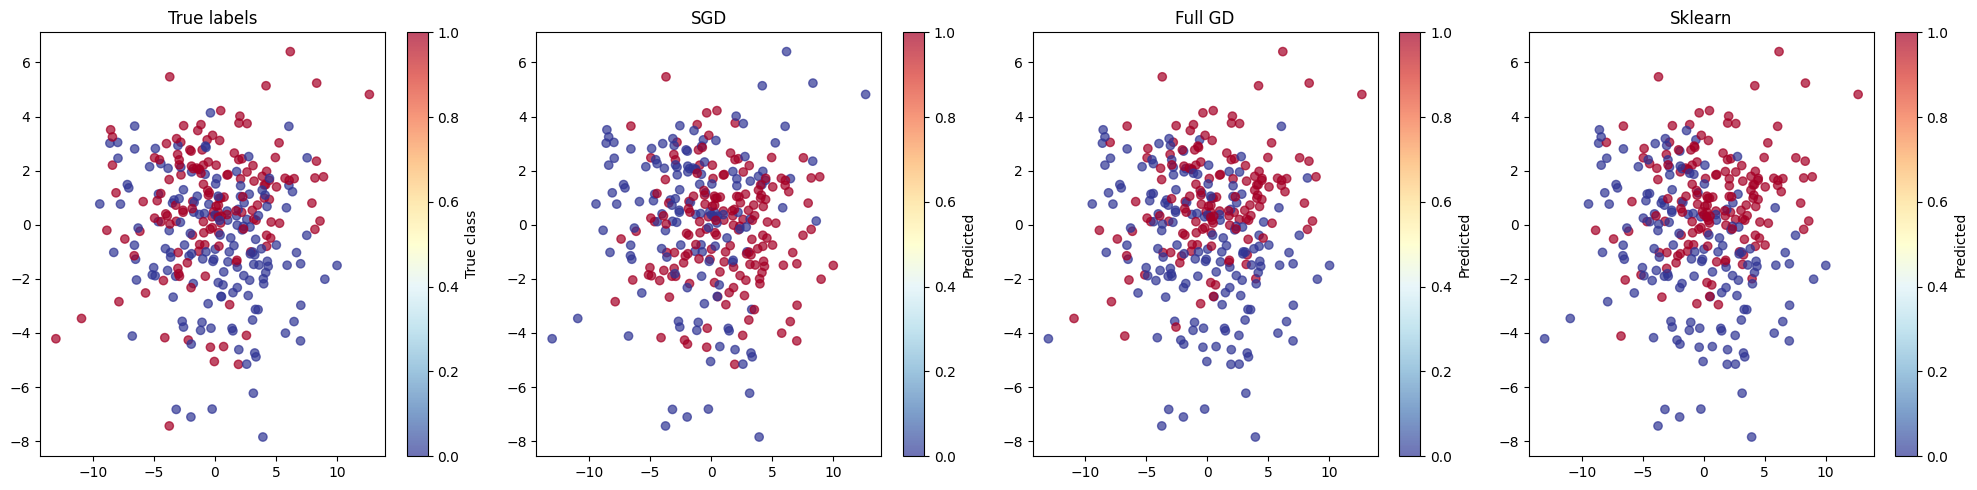

In [11]:
y_pred_sgd = lr_sgd.predict(X_test)
y_pred_full = lr_full.predict(X_test)
y_pred_sklearn = lr_sklearn.predict(X_test)

# PCA с центрированием и масштабированием
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Для сравнения - истинные метки
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Истинные метки
axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                c=y_test, cmap='RdYlBu_r', alpha=0.7)
axes[0].set_title('True labels')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='True class')

# Прогнозы трех моделей
for i, (model_name, y_pred) in enumerate([
    ('SGD', y_pred_sgd),
    ('Full GD', y_pred_full),
    ('Sklearn', y_pred_sklearn)
]):
    axes[i+1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                     c=y_pred, cmap='RdYlBu_r', alpha=0.7)
    axes[i+1].set_title(model_name)
    plt.colorbar(axes[i+1].collections[0], ax=axes[i+1], label='Predicted')

plt.tight_layout()
plt.show()




Анализ различий графиков:

Четкого разделения не видно ни на одном из графиков (даже на истинных значениях):

Full GD и Sklearn больше всего похожи на истинные классы и практически не отличаются между собой (1 точка только). SGD имеет больше шума и хуже разделение.

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [14]:
from sklearn.model_selection import train_test_split

PATH = 'train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [17]:
print("До заполнения:", data.isnull().sum().sum(), "пропусков")
data['keyword'] = data['keyword'].fillna('')
data['location'] = data['location'].fillna('')
data['text'] = data['text'].fillna('')
print("После заполнения:", data.isnull().sum().sum(), "пропусков")
data.head()

До заполнения: 0 пропусков
После заполнения: 0 пропусков


,id,keyword,location,text,target
0,1,,,Our Deeds are the Reason of this #earthquake M...,1
1,4,,,Forest fire near La Ronge Sask. Canada,1
2,5,,,All residents asked to 'shelter in place' are ...,1
3,6,,,"13,000 people receive #wildfires evacuation or...",1
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [18]:
exclude_col = 'text'
numeric_cols = data.select_dtypes(include=['number']).columns
non_text_cols = [col for col in data.columns if col != exclude_col]
unique_counts = {}
for col in non_text_cols:
    unique_count = data[col].nunique()
    unique_counts[col] = unique_count
    print(f"{col}: {unique_count} уникальных")

id: 7613 уникальных
keyword: 222 уникальных
location: 3342 уникальных
target: 2 уникальных


Вывод:

id: идентификатор записи => каждый уникален и не несет информации для предсказания таргеета

keyword: много категорий

location: очень много уникальных записей (почти уникален для каждой записи)

target: бинарная классификация



- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [19]:
class_counts = data['target'].value_counts()
print(class_counts)
print(f"Соотношение: {class_counts[0]} : {class_counts[1]}")

print(f"Процент 0: {class_counts.max()/len(data)*100:.2f}%")
print(f"Процент 1: {class_counts.min()/len(data)*100:.2f}%")

target
0    4342
1    3271
Name: count, dtype: int64
Соотношение: 4342 : 3271
Процент 0: 57.03%
Процент 1: 42.97%


Так есть есть легкий дисбаланс классов, лучше в качесстве метрики выбрать ROC-AUC.

- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [20]:
data_new = data.copy()
data_new ['text'] = data[['keyword', 'location', 'text']].fillna('').agg(' '.join, axis=1)
data_new.head(40)

,id,keyword,location,text,target
0,1,,,Our Deeds are the Reason of this #earthquake...,1
1,4,,,Forest fire near La Ronge Sask. Canada,1
2,5,,,All residents asked to 'shelter in place' ar...,1
3,6,,,"13,000 people receive #wildfires evacuation ...",1
4,7,,,Just got sent this photo from Ruby #Alaska a...,1
5,8,,,#RockyFire Update => California Hwy. 20 clos...,1
6,10,,,#flood #disaster Heavy rain causes flash flo...,1
7,13,,,I'm on top of the hill and I can see a fire ...,1
8,14,,,There's an emergency evacuation happening no...,1
9,15,,,I'm afraid that the tornado is coming to our...,1


- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [21]:
X = data_new['text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)

print(f"Размер: {X_train_counts.shape}")
print(f"Строк: {X_train_counts.shape[0]}")
print(f"Столбцов (уникальных слов): {X_train_counts.shape[1]}")
print(f"Общее кол-во слов: {X_train_counts.sum()}")

Размер: (5329, 18455)
Строк: 5329
Столбцов (уникальных слов): 18455
Общее кол-во слов: 96436


- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [23]:
X_test_counts = count_vect.transform(X_test)
# Обучаем
lr_baseline = LogisticRegression()
lr_baseline.fit(X_train_counts, y_train)


LogisticRegression()

In [33]:
# Метрики
y_pred_proba = lr_baseline.predict_proba(X_test_counts)[:, 1]
roc_auc_metric = roc_auc_score(y_test, y_pred_proba)
print(f" LogReg ROC-AUC: {roc_auc_metric:.4f}")

 LogReg ROC-AUC: 0.8531


Вывод:

Относительно не плохое значение ROC-AUC=0.8531, особенно для сырых данных CountVectorizer без предобработки.

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [25]:
# Обучение
svc_baseline = SVC(probability=True, random_state=42)
start_time = time.time()

svc_baseline.fit(X_train_counts, y_train)

training_time = time.time() - start_time
print(f"Время обучения модельки: {training_time:.2f} сек")


Время обучения модельки: 28.84 сек


In [26]:
# Предсказание и метрики
y_pred_svc_proba = svc_baseline.predict_proba(X_test_counts)[:, 1]
roc_auc_svc = roc_auc_score(y_test, y_pred_svc_proba)
print(f"SVC: ROC-AUC = {roc_auc_svc:.4f}")

SVC: ROC-AUC = 0.8557


Вывод:

Скорость CSV значительно ниже, чем у логистической регрессии (затраченное время 29 секунд, по сравнению с 1 секундой у логистической регрессии).

А roc-auc увеличилась очень незначительно (0.8557 по сравнению с 0.8531).

Получается, что логистическая регрессия предпочтительнее.

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [32]:
count_vect_opt = CountVectorizer(
    max_features=4500,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2
)

X_train_opt = count_vect_opt.fit_transform(X_train)
X_test_opt = count_vect_opt.transform(X_test)

print(f"Новый размер: {X_train_opt.shape}")

Новый размер: (5329, 4500)


In [31]:
# LogisticRegression
lr_opt = LogisticRegression()
lr_opt.fit(X_train_opt, y_train)
y_pred_lr_proba = lr_opt.predict_proba(X_test_opt)[:, 1]

# SVC
svc_opt = SVC(probability=True, random_state=42)
svc_opt.fit(X_train_opt, y_train)
y_pred_svc_proba = svc_opt.predict_proba(X_test_opt)[:, 1]

# Метрики
roc_auc_lr_opt = roc_auc_score(y_test, y_pred_lr_proba)
roc_auc_svc_opt = roc_auc_score(y_test, y_pred_svc_proba)

print(f"LogReg оптимизированный: {roc_auc_lr_opt:.4f}  (5329, 4500)")
print(f"SVC оптимизированный:   {roc_auc_svc_opt:.4f}  (5329, 4500)")

LogReg оптимизированный: 0.7483  (5329, 4500)
SVC оптимизированный:   0.7188  (5329, 4500)


Подобранные гиперпараметры:

max_features=4500 - сокращает количество признаков приблизительно в 4.1 раза, убирает много редких слов (вероятно информативных), ускоряет работу (практически в 2.5 раза), но возможно из-за этого теряется качество предсказания.

ngram_range=(1,2) - оставляет униграммы и биграммы, что по сути должно улучшать качество.

stop_words='english' - выбрасывает общеупотребительные слова, которые не влияют на предсказание целевой переменной (слова по типу - the, a, is, in)

min_df=2 убирает редкие опечатки

### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [53]:
def clean_empty_strings(df, columns):
    """Очищает все типы пустых строк"""
    for col in columns:
        df[col] = (df[col]
                   .fillna('')
                   .replace('', 'missing')
                   .replace(' ', 'missing')
                   .replace(np.nan, 'missing'))
    return df

data_clean = clean_empty_strings(data, ['keyword', 'location'])

# обработка location (берем топ-100 наиболее популярных локаций, остальное как other)
top_locations = data['location'].value_counts().head(100).index
data['location_top'] = np.where(
    data['location'].isin(top_locations),
    data['location'],
    'other'
)

print("Категории:")
print(f"keyword: {data['keyword'].nunique()}")
print(f"location_top: {data['location_top'].nunique()}")

X_df = data[['text', 'keyword', 'location_top']].copy()

Категории:
keyword: 222
location_top: 101


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# разбиение на трейн и тест и onehot
X = data[['text', 'keyword', 'location_top']].copy()
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            CountVectorizer(
                max_features=4500,
                ngram_range=(1, 2),
                stop_words='english',
                min_df=2
            ),
            'text'
        ),
        (
            'keyword',
            OneHotEncoder(
                sparse_output=True,
                handle_unknown='ignore',
                drop='first'
            ),
            ['keyword']
        ),
        (
            'location',
            OneHotEncoder(
                sparse_output=True,
                handle_unknown='ignore',
                drop='first'
            ),
            ['location_top']
        )
    ],
    remainder='drop'
)

X_train_ohe = preprocessor.fit_transform(X_train)
X_test_ohe = preprocessor.transform(X_test)

print("train:", X_train_ohe.shape, "test:", X_test_ohe.shape)

train: (5329, 4821) test: (2284, 4821)


In [61]:
# LogReg
lr_enhanced = LogisticRegression()
lr_enhanced.fit(X_train_ohe, y_train)
y_pred_lr_proba = lr_enhanced.predict_proba(X_test_ohe)[:, 1]
roc_auc_lr_ohe = roc_auc_score(y_test, y_pred_lr_proba)
print(f"ROC-AUC у LogReg после onehot: {roc_auc_lr_ohe:.4f}")

# SVC
svc_enhanced = SVC(probability=True, random_state=42)
svc_enhanced.fit(X_train_ohe, y_train)
y_pred_svc_proba = svc_enhanced.predict_proba(X_test_ohe)[:, 1]
roc_auc_svc_ohe = roc_auc_score(y_test, y_pred_svc_proba)
print(f"ROC-AUC у SVC после onehot: {roc_auc_svc_ohe:.4f}")

ROC-AUC у LogReg после onehot: 0.8528
ROC-AUC у SVC после onehot: 0.8626


Качество значительно улучшилось после кодирования категориальных признаков.

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [78]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform

param_distributions = {
    'C': loguniform(0.01, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    random_state=42,
    verbose=1
)

# Обучаем
random_search.fit(X_train_ohe, y_train)

# Результаты
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"CV ROC-AUC: {random_search.best_score_:.4f}")

# Тестируем
best_lr = random_search.best_estimator_
y_pred_proba = best_lr.predict_proba(X_test_ohe)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры: {'C': np.float64(0.10025956902289568), 'penalty': 'l2', 'solver': 'liblinear'}
CV ROC-AUC: 0.8508
Test ROC-AUC: 0.8633


Полный GridSearchCV работал слишком долго (540 обучений). Поэтому было принято решение использовать RandomizedSearchCV (30 обучений).

Лучшие параметры C=0.1 (оптимальная регуляризация, что снизило переобучение при onehotencoding) , penalty=l2, solver=liblinear.

Произошел небольшой прирост качества.

- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [79]:

param_distributions = {
    'C': loguniform(0.1, 100),
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'class_weight': ['balanced', None]
}

svc_search = RandomizedSearchCV(
    SVC(random_state=42, probability=True),
    param_distributions,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    random_state=42,
    verbose=1
)
# обучаем
svc_search.fit(X_train_ohe, y_train)

# Результаты
print("Лучшие параметры:", svc_search.best_params_)
print("CV ROC-AUC:", svc_search.best_score_)

# Тестируем
best_svc = svc_search.best_estimator_
y_pred_proba = best_svc.predict_proba(X_test_ohe)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Test ROC-AUC:", test_roc_auc)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'C': np.float64(0.1241480428274395), 'class_weight': None, 'gamma': 'auto', 'kernel': 'linear'}
CV ROC-AUC: 0.8463327939556134
Test ROC-AUC: 0.8577911242228591


SVC хуже LogisticRegression, так как выбрано линейное ядро (kernel=linear), а это по сути аналог LogReg, С=0.124 регуляризация похожая как и у logreg. Плюс svc затрачивает гораздо больше времени, а прироста по roc-auc не дает никакого.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [ ]:
# Ваш код здесь

**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤